In [1]:
%pip install -r requirements.txt

  Using cached matplotlib-3.7.0.tar.gz (36.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
   

# Predicting student performance (`score`)

**Task:** predict `score` for the 79 students in `test.rds`; metric = mean squared error (MSE).

**Plan**
1. Explore the training data (distribution, linearity, categorical effects)
2. Feature engineering / transformation
3. Compare several models with **nested cross-validation** (tuning inside, honest error outside)
4. Diagnose fit and over-fitting (train vs CV error, adjusted R², validation & learning curves, residuals)
5. Plot fitted curves against the data, pick the best model, write `predictions.rds`

**Is Ridge/Lasso appropriate for this data?** Yes. There are only n = 316 rows but about 40 predictors once the
categorical variables are dummy-coded, and most predictors are only weakly related to `score`. This is the
regime (small n, many weak/correlated predictors) where shrinkage helps: plain OLS would have high variance,
Ridge stabilises the coefficients, and Lasso additionally drops useless features.

In [2]:
import warnings, subprocess, shutil, glob, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyreadr
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, lasso_path
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (GridSearchCV, KFold, RepeatedKFold, cross_validate,
                                     cross_val_predict, validation_curve, learning_curve, train_test_split)
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
SEED = 42

train = pyreadr.read_r("train.rds")[None]
test = pyreadr.read_r("test.rds")[None]
X_raw = train.drop(columns="score")
y = train["score"].to_numpy()
n = len(train)
print(train.shape, test.shape, "missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head()

(316, 31) (79, 30) missing values: 0 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18.0,U,GT3,T,3.0,2.0,other,services,...,yes,yes,5.0,4.0,3.0,2.0,3.0,1.0,7.0,0.648402
1,GP,F,17.0,U,GT3,T,3.0,4.0,services,other,...,yes,no,4.0,4.0,5.0,1.0,3.0,5.0,16.0,1.169019
2,GP,M,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,no,5.0,2.0,2.0,1.0,1.0,2.0,4.0,0.384039
3,GP,M,18.0,R,GT3,T,4.0,3.0,teacher,services,...,yes,yes,5.0,3.0,2.0,1.0,2.0,4.0,9.0,1.207493
4,GP,F,16.0,U,GT3,T,1.0,3.0,at_home,services,...,yes,yes,4.0,3.0,5.0,1.0,1.0,3.0,0.0,-1.215206


## 1. Exploratory data analysis

Variance of score (= MSE of always predicting the mean): 0.97


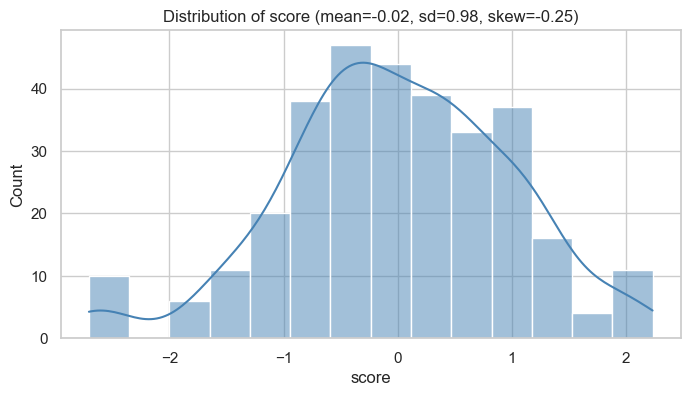

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train["score"], kde=True, ax=ax, color="steelblue")
ax.set_title(f"Distribution of score (mean={y.mean():.2f}, sd={y.std():.2f}, skew={stats.skew(y):.2f})")
print("Variance of score (= MSE of always predicting the mean):", round(y.var(), 3))

`score` looks standardised and roughly normal, so no target transformation is needed.
The MSE of the "predict the mean" baseline is about the variance of `score` (~0.97). Any useful model must beat that.

### Linearity check: numeric predictors (red = LOWESS smoother; a straight red line means a linear relation)

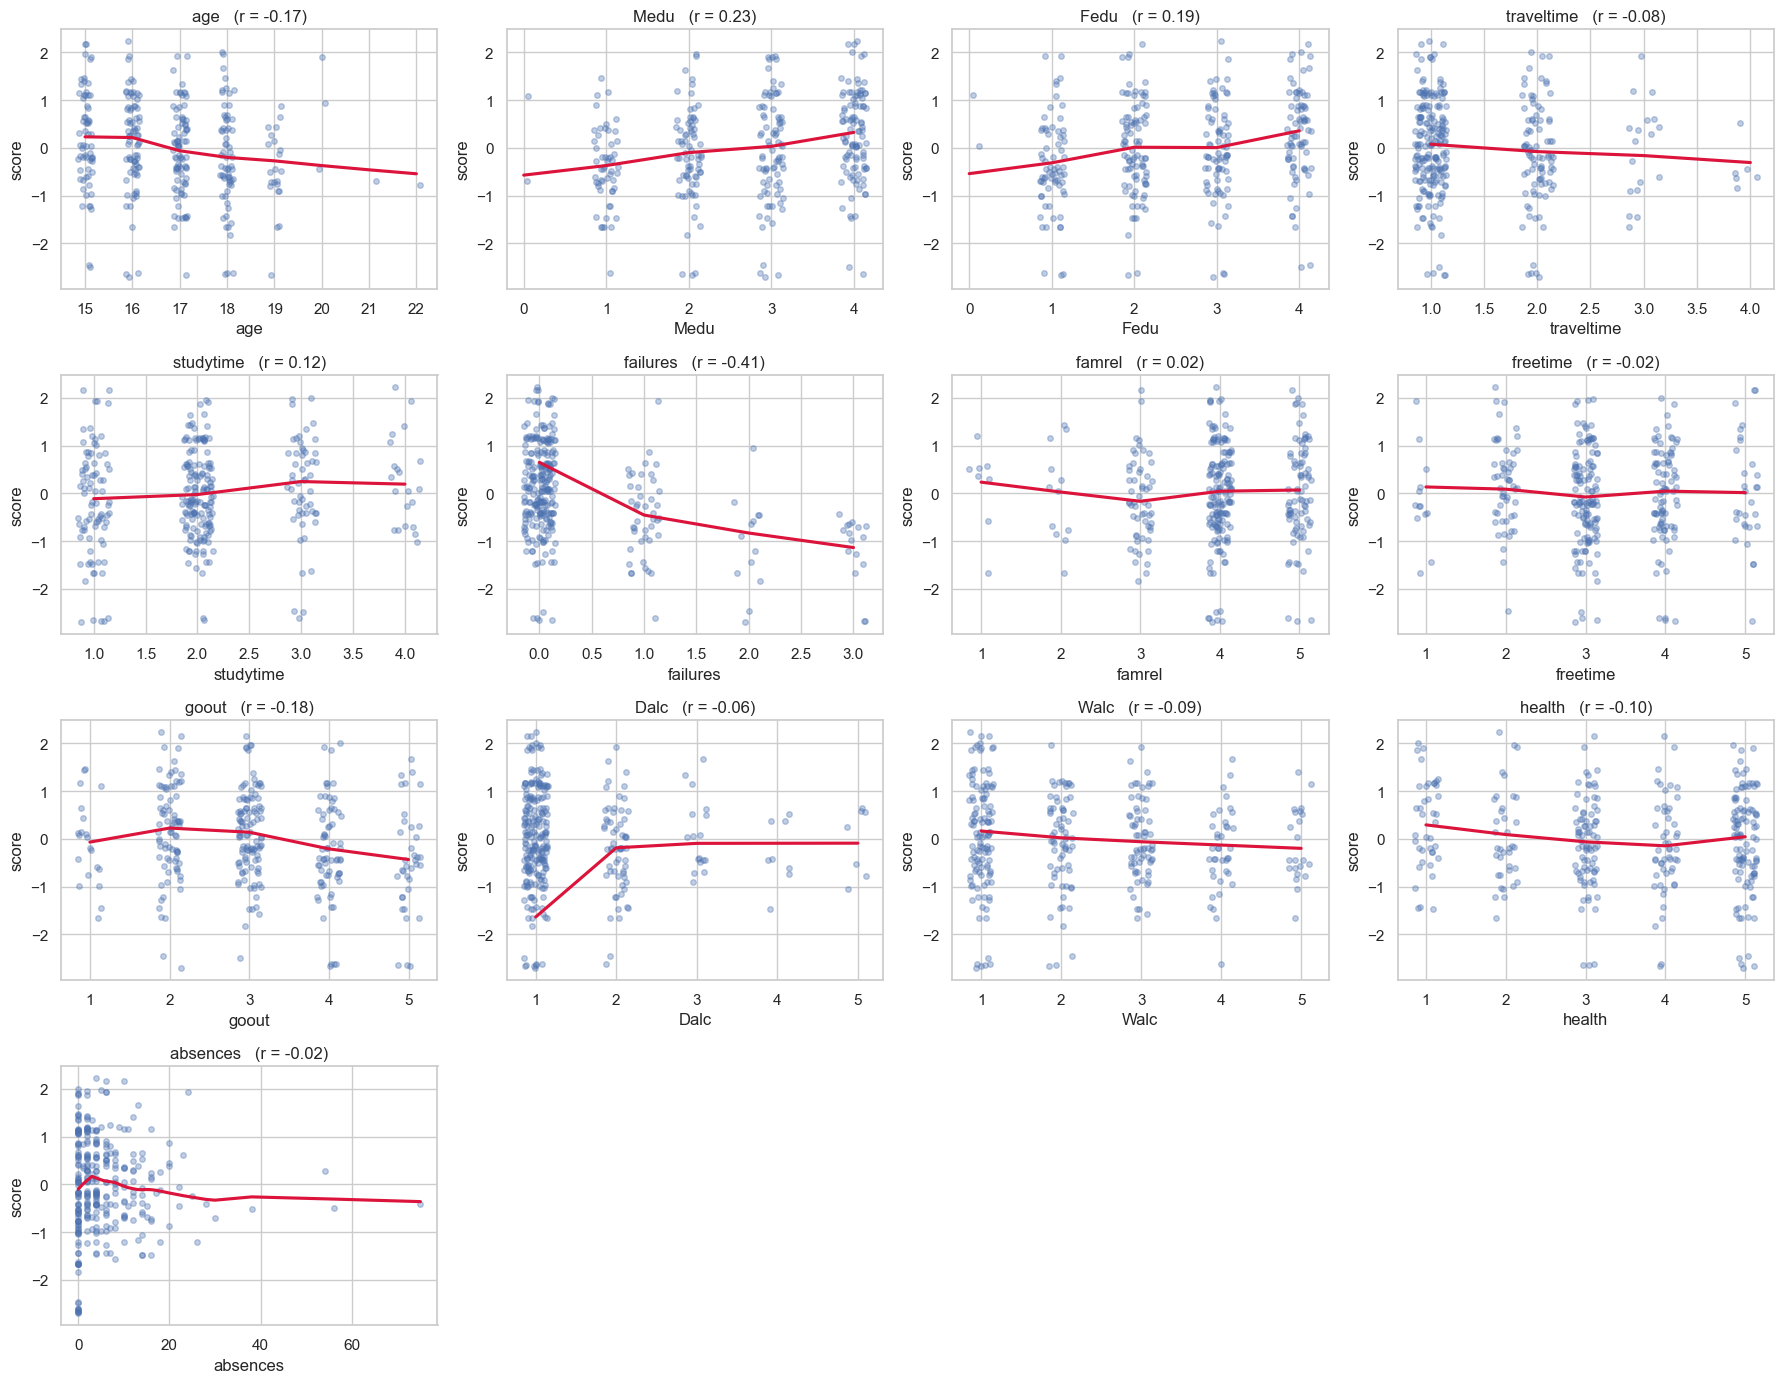

In [4]:
num_cols = X_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(18, 14)); axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.regplot(data=train, x=c, y="score", lowess=True, x_jitter=0.15 if train[c].nunique() <= 20 else 0,
                scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax)
    ax.set_title(f"{c}   (r = {train[c].corr(train['score']):.2f})")
for ax in axes[len(num_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Categorical predictors

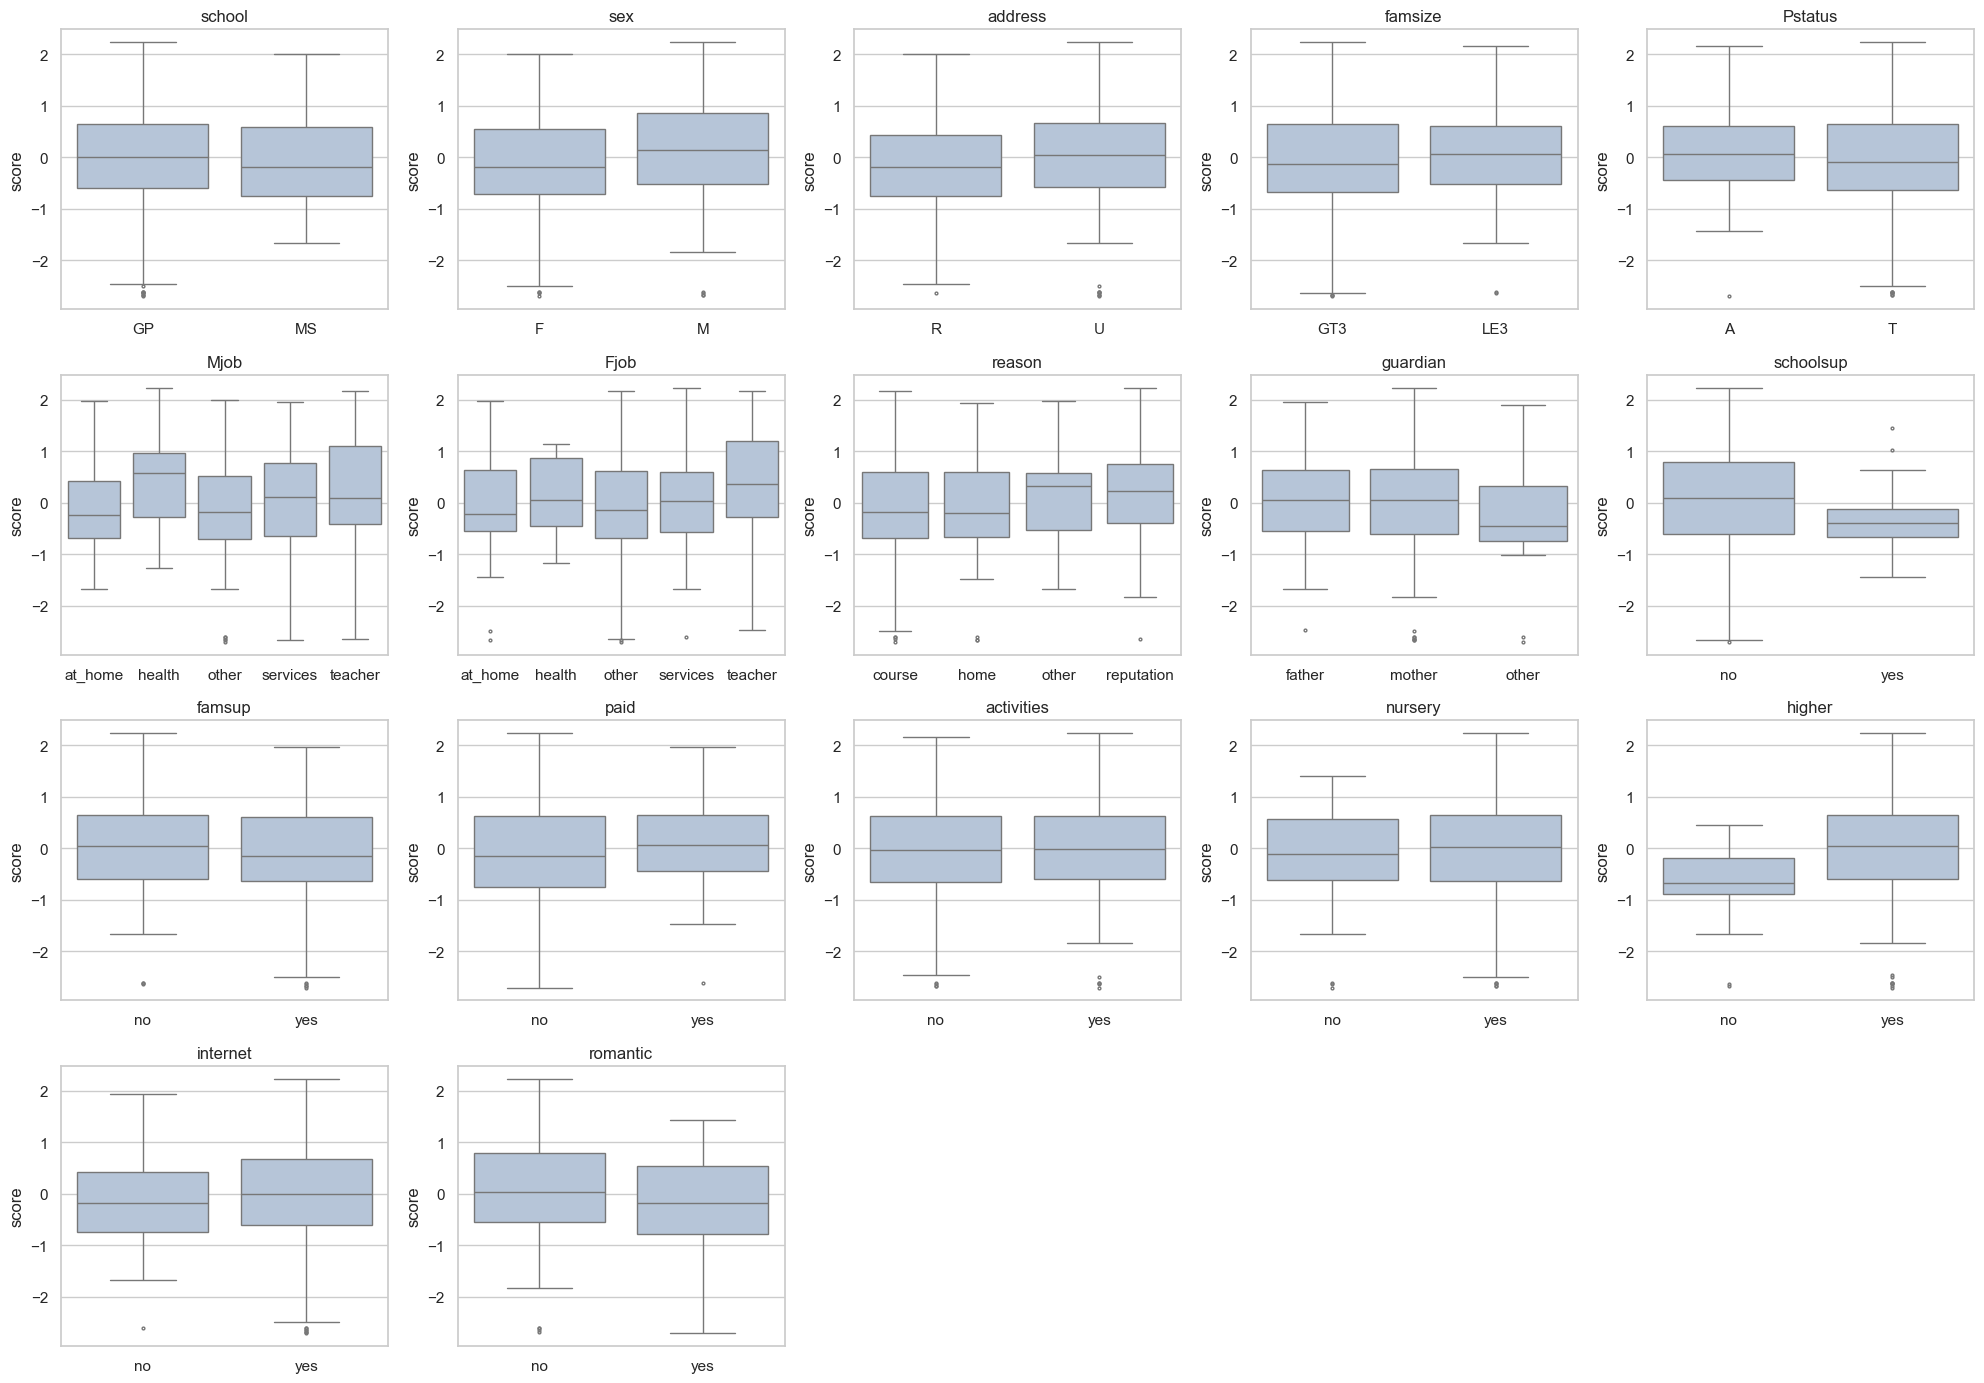

In [5]:
cat_cols = X_raw.select_dtypes("category").columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(20, 14)); axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=train, x=c, y="score", ax=ax, color="lightsteelblue", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
for ax in axes[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Which variables matter on their own? (univariate R² for numeric, η² for categorical) + correlation heatmap

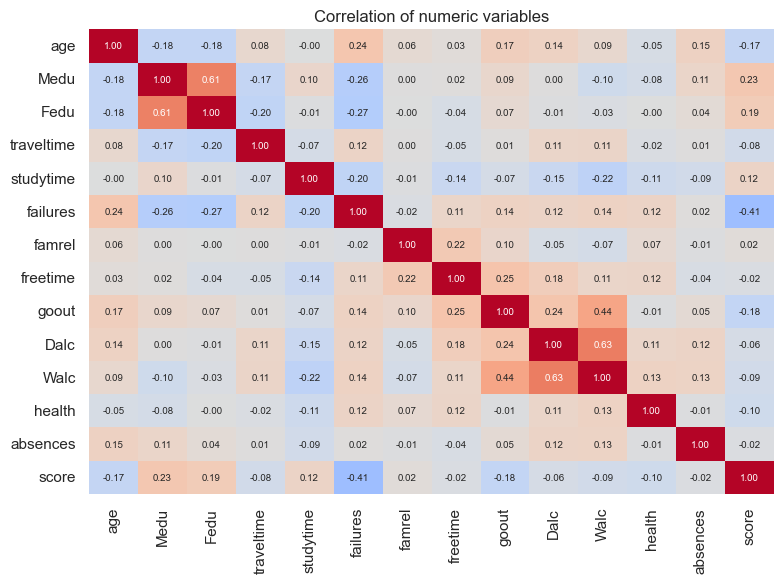

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables")
plt.tight_layout(); plt.show()

**What the plots say**
* Relationships are mostly weak and roughly linear. The strongest single signals are `failures` (clearly negative), `Medu`/`Fedu` and `Mjob` (positive), `goout` (negative), `higher`, `schoolsup`, `age`.
* `absences` is heavily right-skewed (many zeros, a few very large values) and shows no clear linear pattern, so it needs a transformation.
* The predictors are ordinal (1–5) with few levels, so linear trends are plausible but not guaranteed. The tree-based models test that.
* Because the signal is weak, expect a modest R². A large gap between train and CV error would be the main risk, which favours regularised models.

## 2. Feature engineering

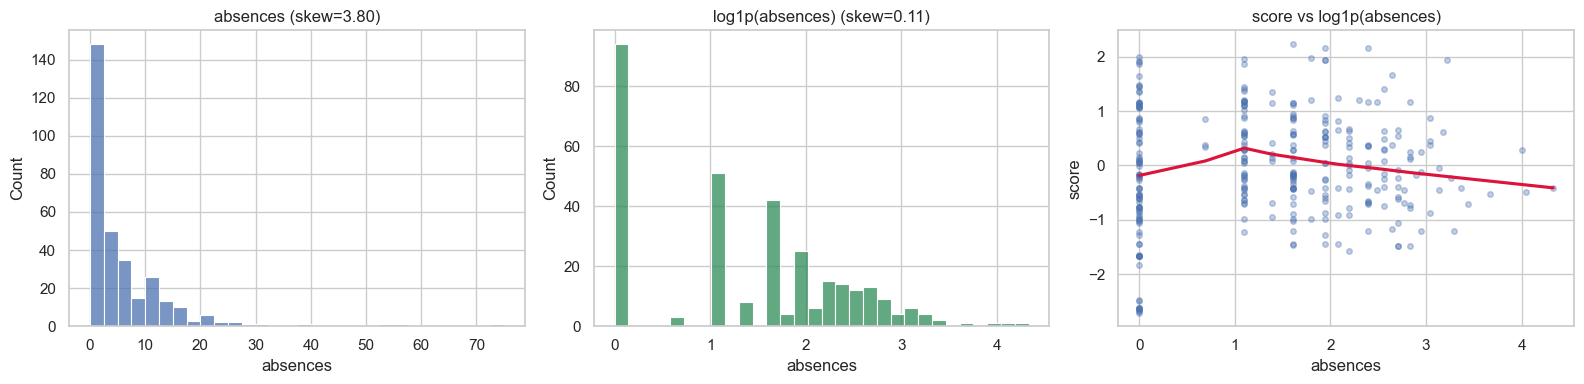

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train["absences"], bins=30, ax=ax[0]); ax[0].set_title(f"absences (skew={stats.skew(train['absences']):.2f})")
la = np.log1p(train["absences"])
sns.histplot(la, bins=30, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p(absences) (skew={stats.skew(la):.2f})")
sns.regplot(x=la, y=train["score"], lowess=True, scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("score vs log1p(absences)")
plt.tight_layout(); plt.show()

Feature engineering applied inside every model pipeline (so that no information leaks between CV folds):

| Step | Why |
|---|---|
| `absences` → `log1p(absences)` and a `no_absences` flag | removes the extreme skew, and separates "never absent" from the rest |
| `had_failure` = `failures > 0` | failures is mostly 0 with a few large values, so this adds a threshold effect |
| `Medu × Fedu` | allows an interaction between mother's and father's education |
| One-hot encoding of categoricals (binary → 1 dummy column; variables with 3+ levels → one column per level; unseen levels in new data are ignored) | numeric input for the models |
| Standardisation of every column | required for a fair Ridge/Lasso penalty and for KNN distances |

In [8]:
def engineer(df):
    d = df.copy()
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
    return d.drop(columns="absences")

def no_fe(df):
    return df

def make_pre(fe=engineer):
    return Pipeline([
        ("fe", FunctionTransformer(fe)),
        ("ct", ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
              make_column_selector(dtype_include=["category", "object"]))],
            remainder="passthrough", verbose_feature_names_out=False)),
        ("sc", StandardScaler()),
    ])

pre_demo = make_pre().fit(X_raw)
feat_names = pre_demo.named_steps["ct"].get_feature_names_out()
print(len(feat_names), "model features after encoding:")
print(list(feat_names))

46 model features after encoding:
['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'log_absences', 'no_absences', 'had_failure', 'Medu_x_Fedu']


## 3. Models and tuning

Candidates (all tuned by cross-validation on the training data only):

* **Mean baseline**, **OLS**, **Ridge**, **Lasso**, **Elastic Net** (linear)
* **KNN**, **Regression tree** (simple non-linear)
* **Random forest**, **Gradient boosting** (flexible non-linear)
* **Hierarchical regression** (three theme-based OLS sub-models -- academic, family, lifestyle -- feeding a master OLS; ported from `Hier_Model.R`; no hyper-parameters to tune)

**Validation strategy: nested cross-validation.** The *inner* 5-fold CV chooses the hyper-parameters
(α, k, depth, …); the *outer* 5-fold × 3-repeat CV measures the error of the whole procedure on data never used
for tuning. That gives an honest estimate of the MSE we should expect on the test set. Every model sees the same outer folds, so the comparison is paired and fair.

#### The hierarchical model as a scikit-learn estimator

**What this block is for.** Hierarchical regression is not a built-in scikit-learn model, so this block wraps the three-stage model from `Hier_Model.R` in a class with `fit` / `predict`. Once it behaves like any other estimator it can sit in `MODELS` and be scored by the same nested CV, on the same folds, as Ridge or Random Forest.

**Steps and the logic behind each**

1. **Declare three column blocks** (`ACADEMIC_COLS`, `FAMILY_COLS`, `LIFESTYLE_COLS`) using the column names that `engineer()` produces (`log_absences`, `no_absences`, `had_failure`, `Medu_x_Fedu`).
   *Logic:* the hierarchical idea is to group predictors by theme so that each sub-model summarises one theme. Using the engineered names means this model gets the same feature engineering as every other model in the comparison.
2. **`__init__` only stores the three lists.**
   *Logic:* `clone` and `GridSearchCV` rebuild an estimator from its constructor arguments, so the constructor must store parameters and do nothing else.
3. **`_block_pipe` builds one sub-model:** one-hot encode the block's categorical columns, pass the numeric ones through, then fit OLS.
   *Logic:* OLS needs numbers. `drop="if_binary"` gives yes/no variables one dummy instead of two redundant ones, and `handle_unknown="ignore"` stops a validation fold from crashing on a level that is absent from its training fold. There is no standardisation because OLS predictions do not change when a feature is rescaled.
4. **`fit` runs the three stages in order:** (a) fit one OLS per block to `score`; (b) take each block's fitted values as that block's *proxy*, one number per student (`_proxies` stacks them as three columns in a fixed order); (c) fit a master OLS of `score` on the three proxies.
   *Logic:* the proxies squeeze dozens of encoded predictors into 3 inputs, so the final stage has very few parameters to estimate from 316 rows. One caveat: proxies for the training rows are in-sample fits (as in the R script), so they are slightly optimistic and the master stage may trust them a little too much. Because every stage is refit on each CV training fold only, the CV error is still honest.
5. **`predict` pushes new rows through the stored sub-models (via the same `_proxies` helper), then through the master model.**
   *Logic:* only parameters learned from the training rows are used, so validation rows never influence any stage. Sharing one helper between `fit` and `predict` guarantees the master model sees its inputs in the same order both times.

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

# Column blocks, using the names produced by engineer() in section 2
ACADEMIC_COLS = ["school", "reason", "studytime", "failures", "had_failure",
                 "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]
FAMILY_COLS = ["Medu", "Fedu", "Medu_x_Fedu", "guardian", "Mjob", "Fjob",
               "famsize", "Pstatus", "famrel", "nursery"]
LIFESTYLE_COLS = ["age", "sex", "address", "health", "romantic", "activities",
                  "internet", "freetime", "goout", "Dalc", "Walc"]


class HierarchicalRegressor(RegressorMixin, BaseEstimator):
    """Academic / family / lifestyle sub-models -> proxies -> master OLS (ports Hier_Model.R)."""

    def __init__(self, academic_cols, family_cols, lifestyle_cols):
        self.academic_cols = academic_cols
        self.family_cols = family_cols
        self.lifestyle_cols = lifestyle_cols

    def _block_pipe(self, cols, X):
        cat_cols = [c for c in cols if not pd.api.types.is_numeric_dtype(X[c])]
        ct = ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat_cols)],
            remainder="passthrough")
        return Pipeline([("ct", ct), ("lm", LinearRegression())])

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = np.asarray(y)
        self.blocks_ = {"academic": self.academic_cols, "family": self.family_cols,
                        "lifestyle": self.lifestyle_cols}
        self.sub_pipes_ = {}
        for name, cols in self.blocks_.items():                     # stage 1: one OLS per block
            self.sub_pipes_[name] = self._block_pipe(cols, X).fit(X[cols], y)
        self.master_ = LinearRegression().fit(self._proxies(X), y)  # stage 2: master OLS on the proxies
        return self

    def _proxies(self, X):
        # one column per block (its fitted values), always in the same order (academic, family, lifestyle)
        return np.column_stack([self.sub_pipes_[name].predict(X[cols])
                                for name, cols in self.blocks_.items()])

    def predict(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return self.master_.predict(self._proxies(X))

#### Model registry, nested-CV objects and the `tuned()` helper

**What this block is for.** Defines every candidate model with its tuning grid, the inner/outer CV splitters, and the `tuned()` function that the rest of the notebook calls. Two things changed compared with the original: `pipe()` now treats the hierarchical model differently, and `MODELS` has a new `"Hierarchical"` entry.

**Steps and the logic behind each**

1. **`pipe()`** builds the pipeline for a model. For `HierarchicalRegressor` it applies only `engineer`; every other model still goes through the shared `make_pre()` (engineer, one-hot, standardise).
   *Logic:* the hierarchical model needs named columns so it can split them into blocks, and it encodes each block itself. `make_pre()` would hand it an anonymous standardised matrix in which the blocks can no longer be identified.
2. **`MODELS`** maps each name to `(estimator, grid)`. `"Hierarchical"` gets an empty grid.
   *Logic:* it has no hyper-parameters (plain OLS at every stage), like OLS and the mean baseline. `GridSearchCV` with an empty grid simply fits once.
3. **`inner_cv` and `outer_cv`** are the tuning and evaluation splitters.
   *Logic:* the inner folds choose hyper-parameters; the outer folds score the whole procedure on data never used for tuning. All models share the same outer folds, so differences between models are not caused by different splits.
4. **`tuned()`** wraps a pipeline in `GridSearchCV` scored by negative MSE, and `mse` is an alias for `mean_squared_error`.
   *Logic:* MSE is the assignment metric, so tuning optimises it directly.

Every later cell that loops over `MODELS` (nested CV, results table, comparison chart, final fits) now includes the hierarchical model automatically.

In [ ]:
def pipe(model, fe=engineer):
    if isinstance(model, HierarchicalRegressor):
        # does its own per-block encoding, so it gets the engineered-but-not-yet-encoded frame
        return Pipeline([("fe", FunctionTransformer(fe)), ("m", model)])
    return Pipeline([("pre", make_pre(fe)), ("m", model)])

BASE = "Mean (baseline)"
MODELS = {
    BASE: (DummyRegressor(), {}),
    "OLS": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"m__alpha": np.logspace(-1, 3, 30)}),
    "Lasso": (Lasso(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 30)}),
    "Elastic Net": (ElasticNet(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 15), "m__l1_ratio": [.2, .5, .8]}),
    "KNN": (KNeighborsRegressor(), {"m__n_neighbors": [5, 10, 15, 20, 30, 40, 60], "m__weights": ["uniform", "distance"]}),
    "Tree": (DecisionTreeRegressor(random_state=SEED), {"m__max_depth": [2, 3, 4, 5], "m__min_samples_leaf": [5, 10, 20]}),
    "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=SEED),
                      {"m__max_features": [0.2, 0.4], "m__min_samples_leaf": [3, 8]}),
    "Gradient Boosting": (GradientBoostingRegressor(subsample=0.7, random_state=SEED),
                          {"m__learning_rate": [0.01, 0.03], "m__max_depth": [1, 2], "m__n_estimators": [100, 300]}),
    "Hierarchical": (HierarchicalRegressor(ACADEMIC_COLS, FAMILY_COLS, LIFESTYLE_COLS), {}),
}
inner_cv = KFold(5, shuffle=True, random_state=SEED)
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def tuned(name, fe=engineer, cv=inner_cv):
    model, grid = MODELS[name]
    return GridSearchCV(pipe(model, fe), grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)

mse = mean_squared_error

In [10]:
t0 = time.time()
nested = {}
for name in MODELS:
    nested[name] = cross_validate(tuned(name), X_raw, y, cv=outer_cv, n_jobs=-1, return_train_score=True,
                                  scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    print(f"{name:18s} done ({time.time() - t0:5.0f}s)  CV MSE = {-nested[name]['test_mse'].mean():.4f}")

Mean (baseline)    done (    4s)  CV MSE = 0.9746
OLS                done (    4s)  CV MSE = 0.8529
Ridge              done (   17s)  CV MSE = 0.7849
Lasso              done (   28s)  CV MSE = 0.7870
Elastic Net        done (   49s)  CV MSE = 0.7859
KNN                done (   57s)  CV MSE = 0.8700
Tree               done (   62s)  CV MSE = 0.7909
Random Forest      done (   88s)  CV MSE = 0.7479
Gradient Boosting  done (  102s)  CV MSE = 0.7576


In [11]:
rows = []
for name, r in nested.items():
    cv_mse, tr_mse = -r["test_mse"].mean(), -r["train_mse"].mean()
    rows.append(dict(model=name, CV_MSE=cv_mse,  train_MSE=tr_mse,
                     fold_sd_MSE=(-r["test_mse"]).std(), CV_R2=r["test_r2"].mean(),
                     overfit_ratio=cv_mse / tr_mse))
res = pd.DataFrame(rows).set_index("model").sort_values("CV_MSE")
res.round(4)

,CV_MSE,train_MSE,fold_sd_MSE,CV_R2,overfit_ratio
model,,,,,
Random Forest,0.7479,0.4010,0.1629,0.2248,1.8651
Gradient Boosting,0.7576,0.5655,0.1601,0.2144,1.3398
Ridge,0.7849,0.6485,0.1525,0.1830,1.2103
Elastic Net,0.7859,0.6727,0.1528,0.1826,1.1682
Lasso,0.7870,0.6780,0.1510,0.1810,1.1608
Tree,0.7909,0.7190,0.1651,0.1783,1.1001
OLS,0.8529,0.5955,0.1559,0.1079,1.4321
KNN,0.8700,0.1449,0.1585,0.0948,6.0054
Mean (baseline),0.9746,0.9690,0.1709,-0.0140,1.0058


### Model comparison chart (nested CV): error per fold and train-vs-CV gap (over-fitting check)

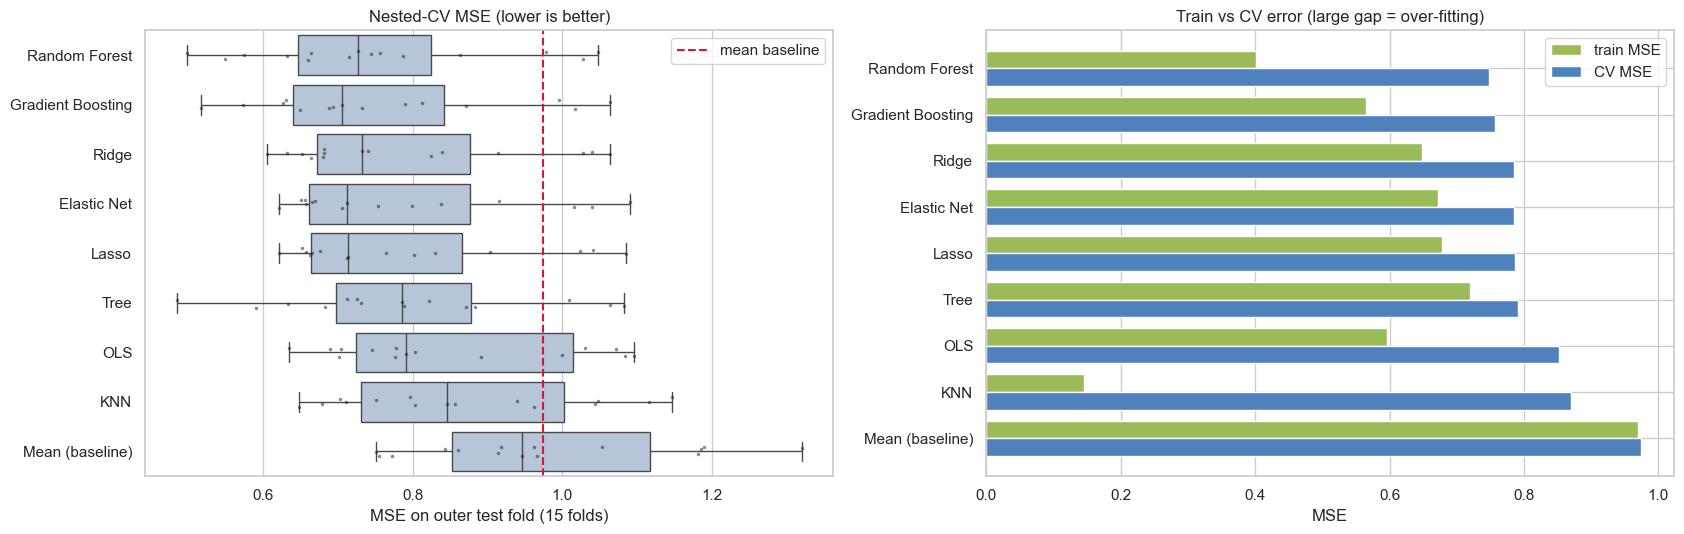

In [12]:
order = res.index.tolist()
fold_mse = pd.DataFrame({k: -nested[k]["test_mse"] for k in order})
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.boxplot(data=fold_mse, orient="h", ax=ax[0], color="lightsteelblue", fliersize=3)
sns.stripplot(data=fold_mse, orient="h", ax=ax[0], color="k", size=2.5, alpha=.5)
ax[0].axvline(res.loc[BASE, "CV_MSE"], color="crimson", ls="--", label="mean baseline")
ax[0].set_xlabel("MSE on outer test fold (15 folds)"); ax[0].set_title("Nested-CV MSE (lower is better)"); ax[0].legend()

w = 0.38; ypos = np.arange(len(order))
ax[1].barh(ypos - w/2, res["train_MSE"], w, label="train MSE", color="#9bbb59")
ax[1].barh(ypos + w/2, res["CV_MSE"], w, label="CV MSE", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(order); ax[1].invert_yaxis()
ax[1].set_xlabel("MSE"); ax[1].set_title("Train vs CV error (large gap = over-fitting)"); ax[1].legend()
plt.tight_layout(); plt.show()

### Do the engineered features help?
Same nested CV, but with raw features (no log/flag/interaction) versus engineered features.

In [13]:
cmp = {}
for name in ["Ridge", "Lasso", "Random Forest"]:
    for lab, fe in [("raw", no_fe), ("engineered", engineer)]:
        r = cross_validate(tuned(name, fe=fe), X_raw, y, cv=outer_cv, n_jobs=-1, scoring="neg_mean_squared_error")
        cmp[(name, lab)] = -r["test_score"].mean()
cmp = pd.Series(cmp).unstack()
cmp["improvement_%"] = 100 * (cmp["raw"] - cmp["engineered"]) / cmp["raw"]
cmp.round(4)

,engineered,raw,improvement_%
Lasso,0.7870,0.8151,3.4399
Random Forest,0.7479,0.7548,0.9139
Ridge,0.7849,0.8181,4.0629


### Hierarchical regression: feature-engineering scenarios and multicollinearity

The hierarchical model uses plain OLS at every stage, with no shrinkage, so collinear predictors inflate its coefficient variance (just as they do for plain OLS above). `Medu × Fedu` is built from `Medu` and `Fedu`, so it is a natural suspect. This section also tests a `Dalc + Walc` combination that is new here (it is not part of `engineer()`).

It does three things: (1) defines switches that turn each engineering step on and off, (2) checks multicollinearity before and after engineering, and (3) measures MSE, R² and adjusted R² of the hierarchical model under several feature sets. Everything is scored on the same `outer_cv` folds as the models above, so the numbers are directly comparable with the `res` table.

#### (a) Feature switches and scenario definitions

**What this block is for.** `build_engineered()` generalises `engineer()` into independent on/off switches and also returns the column lists for the three blocks, so any combination of engineering steps can be built with one call. `SCENARIOS` names the five combinations compared below.

**Steps and the logic behind each**

1. **Copy the input frame.**
   *Logic:* avoids modifying `X_raw` in place, which would leak engineered columns into other cells.
2. **Academic block:** use `log1p(absences)` or raw `absences`; optionally add a `no_absences` flag and a `had_failure` flag next to raw `failures`.
   *Logic:* `absences` is heavily right-skewed with many zeros, so `log1p` compresses the tail while keeping zeros defined, and the flag separates "never absent" from "sometimes absent". `failures` is mostly 0, so `failures > 0` adds a threshold effect that a straight line in `failures` cannot express.
3. **Family block:** optionally add `Medu_x_Fedu` next to `Medu` and `Fedu`.
   *Logic:* the product lets the effect of one parent's education depend on the other's.
4. **Lifestyle block:** optionally add `alc_total = Dalc + Walc` next to `Dalc` and `Walc`.
   *Logic:* weekday and weekend drinking are correlated, and one total is a simpler summary of overall alcohol use.
5. **Return the engineered frame and the three column lists.**
   *Logic:* each sub-model can then select just its own block.
6. **`SCENARIOS`:** the original features, each engineering step alone, then all steps together.
   *Logic:* changing one thing at a time isolates that step's effect, and the last scenario shows the combined effect. Scenario 5 is `engineer()` plus `alc_total`.

In [ ]:
def build_engineered(df, log_absences=False, no_absences_flag=False, had_failure=False,
                     medu_fedu=False, alc_combo=False):
    d = df.copy()

    academic_cols = ["school", "reason", "studytime", "failures", "schoolsup", "paid", "higher", "traveltime"]
    if log_absences:
        d["log_absences"] = np.log1p(d["absences"])
        academic_cols.append("log_absences")
    else:
        academic_cols.append("absences")
    if no_absences_flag:
        d["no_absences"] = (d["absences"] == 0).astype(float)
        academic_cols.append("no_absences")
    if had_failure:
        d["had_failure"] = (d["failures"] > 0).astype(float)
        academic_cols.append("had_failure")

    family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    if medu_fedu:
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols.append("Medu_x_Fedu")

    lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                      "internet", "freetime", "goout", "Dalc", "Walc"]
    if alc_combo:
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols.append("alc_total")

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS = {
    "1. Original (no engineering)": dict(),
    "2. log1p(absences)":           dict(log_absences=True),
    "3. Dalc + Walc combo":         dict(alc_combo=True),
    "4. Medu x Fedu interaction":   dict(medu_fedu=True),
    "5. All features engineered":   dict(log_absences=True, no_absences_flag=True,
                                         had_failure=True, medu_fedu=True, alc_combo=True),
}

#### (b) Multicollinearity before feature engineering: variance inflation factors

**What this block is for.** Puts a number on how strongly each **raw numeric** predictor is explained by the other numeric predictors. `vif_table()` is reused after engineering in block (d), so both tables are computed identically.

**Steps and the logic behind each**

1. **Keep the numeric predictors only** (`numeric_before`).
   *Logic:* the dummy columns of a categorical variable are dependent by construction, which would swamp the diagnostic; the numeric columns are where engineered products and sums cause trouble.
2. **Add a constant column** (`add_constant`).
   *Logic:* each VIF comes from regressing one column on all the others *with an intercept*. Without it the fit is forced through the origin and every VIF is overstated.
3. **For every column, regress it on the others and compute VIF = 1 / (1 − R²).**
   *Logic:* R² says how much of that column the others explain. A VIF of 1 means no overlap, and a VIF above about 5 is the usual warning level because the variance of that coefficient is inflated by the same factor. An exact linear dependence gives R² = 1, so the VIF is infinite.
4. **Drop the constant, sort from largest to smallest and return the table.**
   *Logic:* the worst offenders come first.

In [ ]:
# statsmodels: if missing run  %pip install statsmodels  (and add it to requirements.txt)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant


def vif_table(df, cols):
    X = add_constant(df[cols].astype(float))
    vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return (pd.DataFrame({"feature": X.columns, "VIF": vif})
              .query("feature != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True))


numeric_before = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
                  "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]
vif_before = vif_table(train, numeric_before)
vif_before

#### (c) Correlation heatmap after feature engineering

**What this block is for.** Builds the fully engineered data set (scenario 5) and draws the same kind of correlation heatmap as in section 1, so the two can be compared side by side. This is the "after" picture.

**Steps and the logic behind each**

1. **Build the scenario-5 data set** with `build_engineered()` and attach `score`.
   *Logic:* scenario 5 switches on every engineering step, which is the most collinearity-prone case.
2. **List the engineered numeric columns** (`numeric_after`): raw `absences` is replaced by `log_absences` and `no_absences`, and `had_failure`, `Medu_x_Fedu` and `alc_total` are added.
   *Logic:* these are the columns a model would actually see after engineering.
3. **Draw the heatmap of pairwise correlations, including `score`.**
   *Logic:* pairwise correlation exposes the obvious redundancy. In this data `Medu_x_Fedu` correlates 0.85 with `Medu` and 0.90 with `Fedu`, `alc_total` correlates 0.86 with `Dalc` and 0.94 with `Walc`, `had_failure` 0.87 with `failures`, and `no_absences` −0.83 with `log_absences`. Pairwise correlation cannot show a dependence that involves three or more columns, which is why the VIF is computed next.

In [ ]:
train_full_eng, academic_cols_full, family_cols_full, lifestyle_cols_full = build_engineered(
    X_raw, **SCENARIOS["5. All features engineered"])
train_full_eng["score"] = y

numeric_after = ["age", "Medu", "Fedu", "Medu_x_Fedu", "traveltime", "studytime", "failures", "had_failure",
                 "famrel", "freetime", "goout", "Dalc", "Walc", "alc_total", "health",
                 "log_absences", "no_absences"]

plt.figure(figsize=(9, 7))
sns.heatmap(train_full_eng[numeric_after + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables -- after feature engineering")
plt.tight_layout(); plt.show()

#### (d) Multicollinearity after feature engineering: variance inflation factors

**What this block is for.** Computes the same VIF table as block (b), now for the engineered numeric columns.

**Steps and the logic behind each**

1. **Call `vif_table()` on `train_full_eng[numeric_after]`.**
   *Logic:* the identical procedure (constant, regress each column on the rest, 1 / (1 − R²)) makes "before" and "after" directly comparable.
2. **Read the table for two kinds of problem.**
   *Logic:* `alc_total` is exactly `Dalc + Walc`, so those three columns are perfectly dependent and get an infinite VIF (a huge number on some versions). `Medu_x_Fedu` overlaps strongly with its parents: in our run it is about 25 and `Fedu` about 11. Everything else stays below 5. This is what motivates the "either / or" design in block (i): a derived column should replace its parents rather than sit next to them.

In [ ]:
vif_after = vif_table(train_full_eng, numeric_after)
vif_after

#### (e) Before vs after VIF chart

**What this block is for.** Shows the two VIF tables as bar charts so the change caused by engineering is visible at a glance.

**Steps and the logic behind each**

1. **Cap the plotted values at `CAP = 30`.**
   *Logic:* an infinite VIF cannot be drawn, and matplotlib silently omits such bars, which would make the worst offenders look harmless. Capping keeps them visible.
2. **Draw the two panels on a shared x-axis** with a dashed line at VIF = 5.
   *Logic:* a shared axis makes bar lengths comparable across the two panels, and 5 is the common warning threshold.
3. **Write "∞" next to any bar that hit the cap.**
   *Logic:* tells the reader the true value is at least the cap (or infinite), not exactly 30.

In [ ]:
CAP = 30   # VIFs above this are drawn at CAP and marked with an infinity sign
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for a, (vt, colour, title) in zip(ax, [(vif_before, "lightsteelblue", "Before feature engineering"),
                                        (vif_after, "#4f81bd", "After feature engineering")]):
    sns.barplot(data=vt.assign(VIF_plot=vt["VIF"].clip(upper=CAP)), y="feature", x="VIF_plot", ax=a, color=colour)
    a.axvline(5, color="crimson", ls="--", lw=1)
    a.set_title(title); a.set_xlabel("VIF (dashed line = 5)"); a.set_ylabel("")
    for i, v in enumerate(vt["VIF"]):
        if v > CAP:
            a.text(CAP, i, " ∞", va="center", fontweight="bold")
ax[0].set_xlim(0, CAP * 1.15)
plt.tight_layout(); plt.show()

#### (f) Scoring function for any hierarchical feature set

**What this block is for.** `run_hier_cv()` scores one feature set (data frame plus the three column lists) and returns CV MSE, CV R², adjusted R² and the number of parameters. Every scenario below calls it, so all of them are evaluated identically.

**Steps and the logic behind each**

1. **Build a `HierarchicalRegressor` from the three column lists.**
   *Logic:* the scenarios differ only in which columns each block contains, so the model class is reused unchanged.
2. **Run `cross_validate` on `outer_cv` with MSE and R² scoring.**
   *Logic:* these are the same 15 outer folds used for every model in the comparison table, so scenario results are directly comparable with `res`. There is nothing to tune, so plain CV is already an honest estimate here.
3. **Average the fold scores** (MSE is stored negated by scikit-learn, hence the minus sign).
   *Logic:* the mean over 15 folds is more stable than any single split.
4. **Refit once on all rows and count the parameters:** every encoded column across the three sub-models, plus 3 for the master model's proxy coefficients.
   *Logic:* the count is the model's complexity, which adjusted R² needs.
5. **Compute adjusted R² = 1 − (1 − R²)(n − 1) / (n − p − 1)** with `n` = number of rows and `p` = the parameter count.
   *Logic:* R² can only rise as predictors are added, so adjusted R² discounts it by the degrees of freedom used. Here the input is the out-of-sample CV R² rather than the usual in-sample R², a practical stand-in: a scenario scores higher only if it improves CV R² by more than the extra parameters cost.

In [ ]:
def run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols, cv=outer_cv):
    model = HierarchicalRegressor(academic_cols, family_cols, lifestyle_cols)
    r = cross_validate(model, df_eng, y, cv=cv, scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    cv_mse, cv_r2 = -r["test_mse"].mean(), r["test_r2"].mean()

    model.fit(df_eng, y)                                   # full-data fit, only to count parameters
    p_total = sum(sp.named_steps["lm"].coef_.size for sp in model.sub_pipes_.values()) + 3
    n_total = len(df_eng)
    adj_r2 = 1 - (1 - cv_r2) * (n_total - 1) / (n_total - p_total - 1)

    return dict(CV_MSE=cv_mse, CV_R2=cv_r2, Adjusted_R2=adj_r2, n_params=p_total)

#### (g) Compare the five feature-engineering scenarios

**What this block is for.** Runs `run_hier_cv()` for each scenario in `SCENARIOS` and collects the results in one table (`scen_results`).

**Steps and the logic behind each**

1. **Loop over `SCENARIOS`.**
   *Logic:* each entry is a set of switches for `build_engineered()`.
2. **Build that scenario's features and block lists, then score them with `run_hier_cv()`.**
   *Logic:* the folds are identical for every scenario, so the comparison is paired: differences in MSE, R² and adjusted R² come from the features, not from different train/validation splits.
3. **Stack the results into a table indexed by scenario.**
   *Logic:* one row per scenario makes the trade-offs easy to read. Lower MSE is better, higher R² and adjusted R² are better, and `n_params` shows what each scenario costs in complexity.

In [ ]:
scen_rows = []
for scenario_name, flags in SCENARIOS.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered(X_raw, **flags)
    scen_rows.append(dict(scenario=scenario_name,
                          **run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols)))

scen_results = pd.DataFrame(scen_rows).set_index("scenario")
scen_results.round(4)

#### (h) Scenario chart

**What this block is for.** Draws `scen_results` so the scenarios can be compared visually.

**Steps and the logic behind each**

1. **Left panel: CV MSE per scenario as horizontal bars.**
   *Logic:* MSE is the assignment metric, so it gets its own panel (lower is better).
2. **Right panel: CV R² and adjusted R² side by side for each scenario.**
   *Logic:* the gap between the two bars is the complexity penalty. A scenario whose adjusted R² falls well below its CV R² is paying for parameters it does not earn back.
3. **Reverse the y-axis on both panels.**
   *Logic:* scenarios then read from top to bottom in the same order as the table.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
scen_results["CV_MSE"].plot.barh(ax=ax[0], color="#4f81bd"); ax[0].invert_yaxis()
ax[0].set_xlabel("CV MSE (lower is better)"); ax[0].set_title("Hierarchical model MSE by scenario")

w = 0.38; ypos = np.arange(len(scen_results))
ax[1].barh(ypos - w/2, scen_results["CV_R2"], w, label="CV R2", color="#9bbb59")
ax[1].barh(ypos + w/2, scen_results["Adjusted_R2"], w, label="Adjusted R2", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(scen_results.index); ax[1].invert_yaxis()
ax[1].set_xlabel("R2 (higher is better)"); ax[1].set_title("CV R2 vs Adjusted R2"); ax[1].legend()
plt.tight_layout(); plt.show()

#### (i) Either / or feature builder and the 2 × 2 design

**What this block is for.** Blocks (d) and (e) showed that keeping a derived column next to its parents creates collinearity. `build_engineered_v2()` therefore uses **either** the parents **or** the derived column, and `SCENARIOS_V2` covers all four combinations (a 2 × 2 design: two choices for the education pair times two choices for the alcohol pair).

**Steps and the logic behind each**

1. **Always build `log_absences`, `no_absences` and `had_failure`.**
   *Logic:* their VIFs were all below 5, so they are not part of the problem and stay on in every scenario, which isolates the two questionable pairs.
2. **Family block: `medu_fedu_mode="raw"` keeps `Medu` and `Fedu`; `"interaction"` keeps only `Medu_x_Fedu`.**
   *Logic:* the product carries the interaction, and dropping its parents removes the collinearity, at the price of losing the separate main effects.
3. **Lifestyle block: `alc_mode="raw"` keeps `Dalc` and `Walc`; `"combo"` keeps only `alc_total`.**
   *Logic:* the total is an exact sum of the two columns, so keeping all three is a perfect linear dependence. Using the total alone removes it and gives up the weekday/weekend distinction.
4. **`SCENARIOS_V2` lists the four combinations A to D.**
   *Logic:* a full grid shows each choice's effect and whether they interact. A is the plain baseline and D is the most compressed feature set.

In [ ]:
def build_engineered_v2(df, medu_fedu_mode="raw", alc_mode="raw"):
    """medu_fedu_mode: "raw" (Medu + Fedu) or "interaction" (Medu_x_Fedu only)
       alc_mode:       "raw" (Dalc + Walc) or "combo" (alc_total only)
       Never includes both sides of either pair -- that is what caused VIF = inf."""
    d = df.copy()

    # academic block unchanged: log_absences / no_absences / had_failure all had VIF < 5
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    academic_cols = ["school", "reason", "studytime", "failures", "had_failure",
                     "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]

    # family block: EITHER raw Medu/Fedu OR the interaction -- never both
    if medu_fedu_mode == "interaction":
        d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
        family_cols = ["Medu_x_Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]
    else:
        family_cols = ["Medu", "Fedu", "guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery"]

    # lifestyle block: EITHER raw Dalc/Walc OR the combined total -- never both
    if alc_mode == "combo":
        d["alc_total"] = d["Dalc"] + d["Walc"]
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                          "internet", "freetime", "goout", "alc_total"]
    else:
        lifestyle_cols = ["age", "sex", "address", "health", "romantic", "activities",
                          "internet", "freetime", "goout", "Dalc", "Walc"]

    return d, academic_cols, family_cols, lifestyle_cols


SCENARIOS_V2 = {
    "A. Dalc+Walc raw  / Medu+Fedu raw": dict(medu_fedu_mode="raw",         alc_mode="raw"),
    "B. Dalc+Walc raw  / Medu x Fedu":   dict(medu_fedu_mode="interaction", alc_mode="raw"),
    "C. alc_total      / Medu+Fedu raw": dict(medu_fedu_mode="raw",         alc_mode="combo"),
    "D. alc_total      / Medu x Fedu":   dict(medu_fedu_mode="interaction", alc_mode="combo"),
}

#### (j) Score the four either / or models

**What this block is for.** Evaluates the four models A to D with `run_hier_cv()` and stores the results in `scen_results_2x2`.

**Steps and the logic behind each**

1. **Loop over `SCENARIOS_V2`, build each feature set with `build_engineered_v2()`.**
   *Logic:* each scenario is one cell of the 2 × 2 grid.
2. **Score each with the same `run_hier_cv()` on the same `outer_cv` folds.**
   *Logic:* identical scoring means any difference between A, B, C and D is caused by the feature choice alone.
3. **Collect one row per scenario.**
   *Logic:* MSE and CV R² show which representation predicts best, and `n_params` and adjusted R² show whether a more compact representation is worth it.

In [ ]:
scen2_rows = []
for scenario_name, flags in SCENARIOS_V2.items():
    df_eng, academic_cols, family_cols, lifestyle_cols = build_engineered_v2(X_raw, **flags)
    scen2_rows.append(dict(scenario=scenario_name,
                           **run_hier_cv(df_eng, y, academic_cols, family_cols, lifestyle_cols)))

scen_results_2x2 = pd.DataFrame(scen2_rows).set_index("scenario")
scen_results_2x2.round(4)

#### (k) Where do the hierarchical variants rank against the other models?

**What this block is for.** Puts every hierarchical variant into one leaderboard together with the models from the nested-CV table `res`, sorted by CV MSE. The row `Hierarchical` is the version registered in `MODELS` (all `engineer()` features, `Medu`, `Fedu` and `Medu_x_Fedu` together).

**Steps and the logic behind each**

1. **Take `CV_MSE` and `CV_R2` from `res`, `scen_results` and `scen_results_2x2`.**
   *Logic:* all three were computed on the same 15 outer folds, so the numbers can be compared directly.
2. **Prefix the hierarchical scenario names** (`Hier |` and `Hier 2x2 |`).
   *Logic:* keeps them distinguishable from the model names in `res`.
3. **Concatenate and sort by CV MSE.**
   *Logic:* MSE is the selection metric, so the top row is the best out-of-sample performer. If a hierarchical variant tops the table, set `best_name` in section 5 accordingly (for a variant, first update `FAMILY_COLS` / `LIFESTYLE_COLS` above to match it and re-run from the model registry).

In [ ]:
leaderboard = pd.concat([
    res[["CV_MSE", "CV_R2"]],
    scen_results[["CV_MSE", "CV_R2"]].rename(index=lambda s: f"Hier | {s}"),
    scen_results_2x2[["CV_MSE", "CV_R2"]].rename(index=lambda s: f"Hier 2x2 | {s}"),
]).sort_values("CV_MSE")
leaderboard.round(4)

## 4. Fit and over-fitting diagnostics

### 4a. Adjusted R² for the linear models
In-sample R² always rises when predictors are added, so it is adjusted for the number of predictors *p* (for the penalised models, *p* = number of non-zero coefficients). The table compares it to the **cross-validated R²**. The gap between the two is a direct measure of over-fitting.

In [14]:
def format_param(v):
    try:
        return round(float(v), 4)
    except (ValueError, TypeError):
        return v

final_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)   # more stable tuning for the final fits
fitted = {name: tuned(name, cv=final_cv).fit(X_raw, y) for name in MODELS}

rows = []
for name in ["OLS", "Ridge", "Lasso", "Elastic Net", "KNN", "Tree", "Random Forest", "Gradient Boosting"]:
    #est = fitted[name].best_estimator_
    rows.append(dict(model=name, best_params={k.replace("m__", ""): format_param(v) for k, v in fitted[name].best_params_.items()}
                     ))
pd.DataFrame(rows).set_index("model").round(4)

,best_params
model,
OLS,{}
Ridge,{'alpha': 148.7352}
Lasso,{'alpha': 0.0474}
Elastic Net,"{'alpha': 0.2062, 'l1_ratio': 0.2}"
KNN,"{'n_neighbors': 15.0, 'weights': 'distance'}"
Tree,"{'max_depth': 2.0, 'min_samples_leaf': 20.0}"
Random Forest,"{'max_features': 0.4, 'min_samples_leaf': 3.0}"
Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 2.0, 'n_e..."


### 4b. Validation curves: train vs CV error as model complexity changes

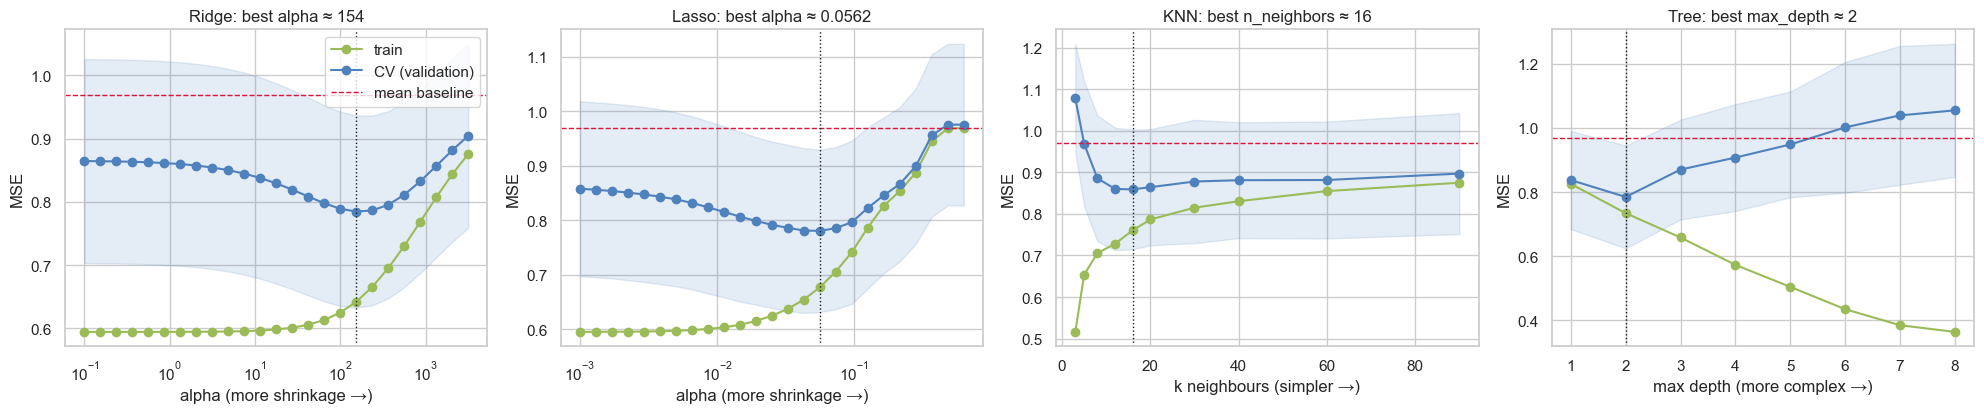

In [15]:
vc_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)
specs = [("Ridge", "m__alpha", np.logspace(-1, 3.5, 25), "alpha (more shrinkage →)", True),
         ("Lasso", "m__alpha", np.logspace(-3, -0.2, 25), "alpha (more shrinkage →)", True),
         ("KNN", "m__n_neighbors", np.array([3, 5, 8, 12, 16, 20, 30, 40, 60, 90]), "k neighbours (simpler →)", False),
         ("Tree", "m__max_depth", np.arange(1, 9), "max depth (more complex →)", False)]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, (name, par, rng, xl, logx) in zip(axes, specs):
    model, _ = MODELS[name]
    base = pipe(model)
    if name == "Tree": base.set_params(m__min_samples_leaf=5)
    if name == "KNN": base.set_params(m__weights="uniform")
    tr, va = validation_curve(base, X_raw, y, param_name=par, param_range=rng, cv=vc_cv,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    tr, va = -tr, -va
    ax.plot(rng, tr.mean(1), "o-", label="train", color="#9bbb59")
    ax.plot(rng, va.mean(1), "o-", label="CV (validation)", color="#4f81bd")
    ax.fill_between(rng, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=.15, color="#4f81bd")
    ax.axhline(y.var(), color="crimson", ls="--", lw=1, label="mean baseline")
    b = va.mean(1).argmin(); ax.axvline(rng[b], color="k", ls=":", lw=1)
    if logx: ax.set_xscale("log")
    ax.set_title(f"{name}: best {par.split('__')[1]} ≈ {rng[b]:.3g}"); ax.set_xlabel(xl); ax.set_ylabel("MSE")
axes[0].legend()
plt.tight_layout(); plt.show()

### 4c. Lasso coefficient path and the final Ridge / Lasso coefficients

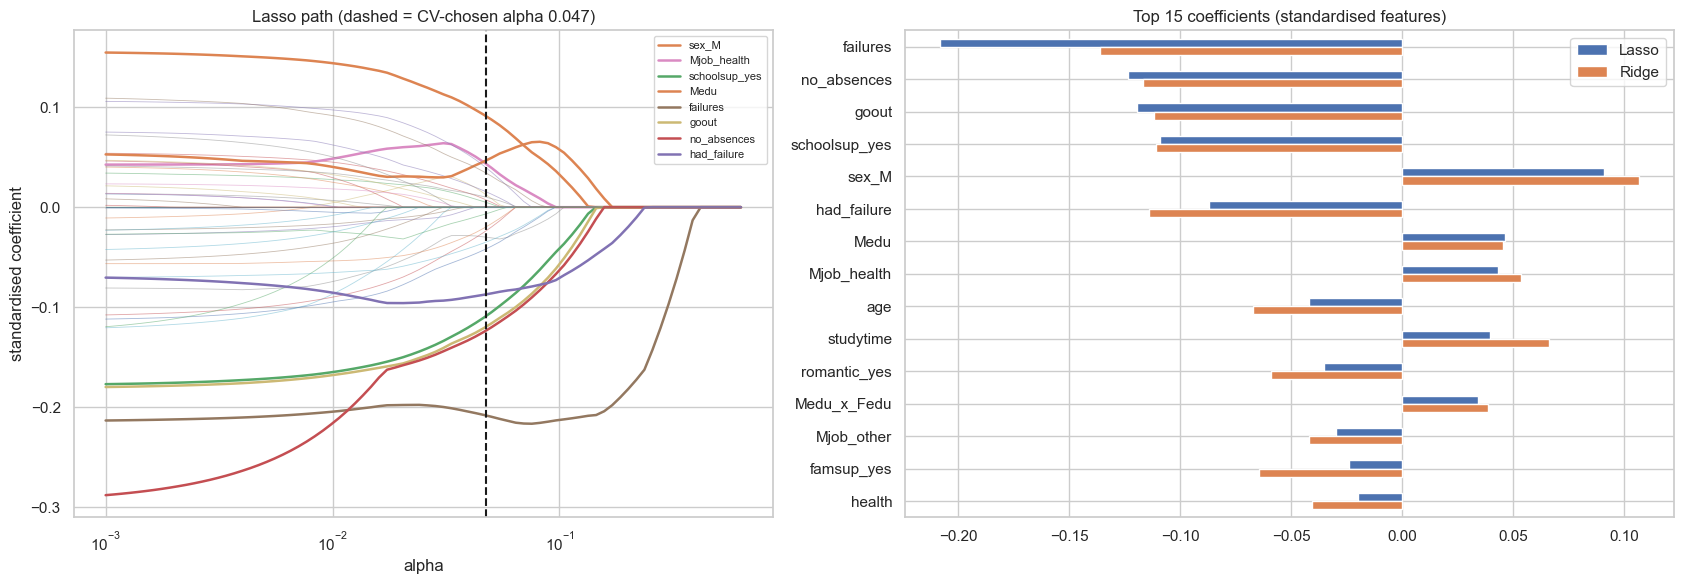

Lasso keeps 21 of 46 features


In [16]:
Xt = make_pre().fit_transform(X_raw)
alphas_path, coefs, _ = lasso_path(Xt, y, alphas=np.logspace(-3, -0.2, 80))

a_lasso = fitted["Lasso"].best_params_["m__alpha"]
lasso_coef = pd.Series(fitted["Lasso"].best_estimator_.named_steps["m"].coef_, index=feat_names)
ridge_coef = pd.Series(fitted["Ridge"].best_estimator_.named_steps["m"].coef_, index=feat_names)
top = lasso_coef.abs().sort_values(ascending=False).index[:8]

fig, ax = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw=dict(width_ratios=[1, 1.1]))
for j, f in enumerate(feat_names):
    hi = f in top
    ax[0].plot(alphas_path, coefs[j], lw=1.8 if hi else .6, alpha=1 if hi else .5, label=f if hi else None)
ax[0].set_xscale("log"); ax[0].axvline(a_lasso, color="k", ls="--"); ax[0].set_xlabel("alpha"); ax[0].set_ylabel("standardised coefficient")
ax[0].set_title(f"Lasso path (dashed = CV-chosen alpha {a_lasso:.3f})"); ax[0].legend(fontsize=8)

sel = (lasso_coef.abs().sort_values(ascending=False).index[:15])
cdf = pd.DataFrame({"Lasso": lasso_coef[sel], "Ridge": ridge_coef[sel]})
cdf.plot.barh(ax=ax[1]); ax[1].invert_yaxis(); ax[1].set_title("Top 15 coefficients (standardised features)")
plt.tight_layout(); plt.show()
print(f"Lasso keeps {int((lasso_coef != 0).sum())} of {len(lasso_coef)} features")

## 5. Final model and predictions for `test.rds`

The model with the lowest nested-CV MSE is refit on **all** 316 training rows (with its hyper-parameters re-tuned by repeated CV) and used to predict the 79 test students.

Selected model: Random Forest
Hyper-parameters: {'m__max_features': 0.4, 'm__min_samples_leaf': 3}
Expected test MSE (nested CV): 0.7479,  mean-baseline MSE 0.9746

Predictions:
 [ 0.46965787  0.02679961  0.40593161 -0.02592224 -0.02858495  0.78123788
  0.55582085  0.46931052  0.85983375  0.54648045 -0.17395515  0.23332239
  0.24376888 -0.37219257  0.32290614  0.44778047  0.34885026 -0.45777546
  0.69854468 -0.088396    0.57327841  0.29775615  0.18745002  0.03227212
  0.22959493 -0.44732019  0.53108352  0.19260261 -0.57064775  0.54300373
  0.09617412  0.07953646  0.59968667  0.05431695 -0.48141004 -0.61312591
 -0.08800235  0.08231622  0.06947129  0.11045631  0.22386517  0.66830293
 -0.03190463 -0.12022981 -0.48588358 -0.39160217 -0.3661755  -0.22479746
  0.39637135  0.36011773  0.41183857 -0.86177032  0.05894035  0.3764311
  0.75869798 -0.11634561  0.21651908  0.40909516  0.00797669 -0.25753913
 -0.29991513  0.11905077  0.41988207  0.17083339 -0.23694056  0.21344155
  0.38414132 -0.324

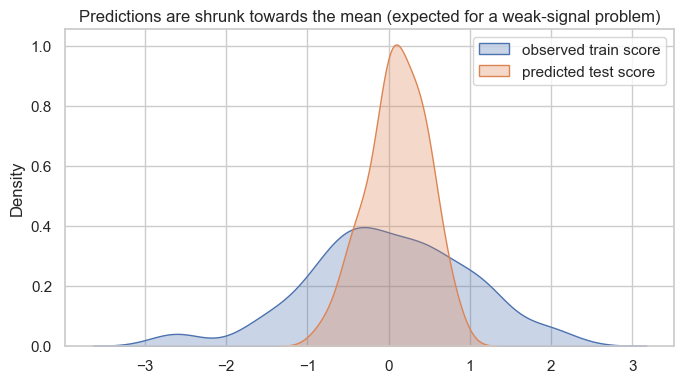

In [17]:
best_name="Random Forest"
final = fitted[best_name]
print("Selected model:", best_name)
print("Hyper-parameters:", final.best_params_)
print(f"Expected test MSE (nested CV): {res.loc[best_name, 'CV_MSE']:.4f},  "
      f"mean-baseline MSE {res.loc[BASE, 'CV_MSE']:.4f}")

pred = final.predict(test)
assert pred.shape == (79,) and np.isfinite(pred).all()
print("\nPredictions:\n", pred)
print("\nPrediction summary:", pd.Series(pred).describe().round(3).to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(y, ax=ax, label="observed train score", fill=True, alpha=.3)
sns.kdeplot(pred, ax=ax, label="predicted test score", fill=True, alpha=.3)
ax.set_title("Predictions are shrunk towards the mean (expected for a weak-signal problem)"); ax.legend()
plt.tight_layout(); plt.show()

Save `predictions.rds` as a plain numeric vector (written with R's `saveRDS`, so `readRDS("predictions.rds")` returns a numeric vector of length 79).

In [18]:
pd.Series(pred).to_csv("_pred_tmp.csv", index=False, header=False, float_format="%.10f")
rscript = shutil.which("Rscript") or (sorted(glob.glob(r"C:\Program Files\R\R-*\bin\Rscript.exe")) or [None])[-1]
print("Rscript:", rscript)
subprocess.run([rscript, "-e",
                "x <- scan('_pred_tmp.csv', quiet=TRUE); saveRDS(as.numeric(x), 'predictions.rds'); "
                "y <- readRDS('predictions.rds'); cat('class:', class(y), ' length:', length(y), '\\n'); print(summary(y))"],
               check=True)
import os; os.remove("_pred_tmp.csv")

Rscript: /usr/local/bin/Rscript
class: numeric  length: 79 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.86177 -0.11029  0.09617  0.10184  0.39026  0.85983 



## 6. Summary of findings

* **Signal is weak.** The best models reach a CV R² of only ~0.22, so the expected test MSE is ~0.75 versus 0.97 for predicting the mean. This is consistent across the nested CV and the independent hold-out check.
* **Ranking (nested CV MSE):** Random Forest 0.749 < Gradient Boosting 0.757 < Ridge 0.785 ≈ Elastic Net 0.786 ≈ Lasso 0.787 ≈ Tree 0.791 < OLS 0.857 < KNN 0.870 < mean 0.975.
  The top models are close relative to the fold-to-fold spread (sd ≈ 0.16), so Random Forest is ahead but not by a wide margin. The regularised linear models are almost as good and more interpretable.
* **Regularisation matters.** Plain OLS (46 features, n = 316) over-fits: in-sample R² 0.35 but CV R² 0.10 (CV-adjusted R² < 0). Ridge/Lasso lift CV R² to ~0.18, and Lasso keeps only 21 of 46 features.
* **Feature engineering helped:** log(absences), the no-absence flag, a failure flag and Medu × Fedu lowered the CV MSE by about 3–4 % for Ridge and Lasso, and by about 1 % for Random Forest.
* **Over-fitting:** KNN (train RMSE ≈ 0.38 vs CV 0.93) and, to a lesser extent, Random Forest (0.63 vs 0.87) have large train/CV gaps. The train error is not a valid guide for those, which is why the selection uses the nested-CV error. Random Forest still has the lowest out-of-sample error.
* **Main drivers:** past `failures`, parents' education, `age`, `goout`, `higher`, `schoolsup`. The fitted curves in section 5b show the models track the observed means for these features.
